In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
from scipy.stats import chi2
from sklearn.preprocessing import LabelEncoder
import re
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from adjustText import adjust_text


# Color mapping (hex codes)
colors = {
    'Cardiac precursor': "#a086bd", 
    'Cardiomyocyte': "#6b4e71",
    'ESC': '#6bcfcf',
    'ESC-derived NPC': '#d4adab', 
    'ESC-derived neurons': '#469433',
    'Fetal NPC': '#967978',
    'Fetal neurons': '#a85858',
    'Heart tissue': "#5f1ea6",
    'Mesodermal cells': "#6bcfcf",
    'NES': '#e8bc64',
    'NPC': '#e38519',
    'NSC': '#e38519',
    'Post-mortem neurons': '#034e91',
    'Adult neurons': '#034e91',
    'Post-mortem non-neurons': '#a87963',
    'iPSC': '#696969',
    'iPSC-derived cardiac mesoderm': "#bfb2cf",  
    'iPSC-derived cardiac precursor': "#a086bd",
    'iPSC-derived cardiomyocyte': "#9955a2",
    'iPSC-derived glia': '#a87963',
    'iPSC-derived neurons': '#469433',
    'iPSC-derived neurons_short': '#b0e8a9',
    'iPSC-derived neurons_medium': '#1fc24a',
    'iPSC-derived neurons_long': '#08472b',
    'Primary fetal neurons': '#a85858',
    "Primary neurons": '#469433'
}

green_shades = {
    'short': '#a1d99b',   # light green
    'medium': '#41ab5d',  # medium green
    'long': '#005a32'     # dark green
}

# Shape mapping (matplotlib marker codes)
shapes = {
    'Fetal neurons': 'o',         # 16 in R = 'o' (circle)
    'Fetal NPC': '^',             # 18 in R = '^' (triangle_up)
    'iPSC-derived neurons': 'o',
    'iPSC-derived neurons_short': 'o',
    'iPSC-derived neurons_medium': 'o',
    'iPSC-derived neurons_long': 'o',
    'iPSC': 'o',
    'NPC': 'o',
    'NSC': '^',
    "NES": 'o',
    "ESC": 'o',
    'ESC-derived NPC': 'o',
    'ESC-derived neurons': '^',
    'Post-mortem neurons': 'o',
    'Post-mortem non-neurons': 'o',
    'Adult neurons': 'o',
    'iPSC-derived glia': 'o',
    'ES-derived neurons': '^',
    'Heart tissue': 'o',
    'iPSC-derived cardiac mesoderm': 'o',
    'iPSC-derived cardiac precursor': 'o',
    'iPSC-derived cardiomyocyte': 'o',
    'Cardiomyocyte': 'v',         # 17 in R = 'v' (triangle_down)
    'Cardiac precursor': 'D',     # 25 in R = 'D' (diamond)
    'Mesodermal cells': '^',
    "Fetal heart tissue": 'v',
    "Primary neurons": 'v',
    'Primary fetal neurons': 'v'
}

# Size mapping (matplotlib s parameter, scale as needed)
sizes = {
    'Fetal neurons': 60,
    'Fetal ES-derived neurons': 60,
    'Fetal NPC': 60,
    'Fetal stem-like cells': 60,
    'iPSC-derived neurons': 60,
     'iPSC-derived neurons_short': 60,
    'iPSC-derived neurons_medium': 60,
    'iPSC-derived neurons_long': 60,
    'ESC-derived NPC': 60,
    'ESC-derived neurons': 60,
    'iPSC': 60,
    'Adult neurons': 60,
    'NPC': 60,
    'NSC': 60,
    "NES": 60,
    "ESC": 60,
    'Post-mortem neurons': 60,
    'Post-mortem non-neurons': 60,
    'iPSC-derived glia': 60,
    'ES-derived neurons': 60,
    'Heart tissue': 60,
    'iPSC-derived cardiac mesoderm': 60,
    'iPSC-derived cardiac precursor': 60,
    'iPSC-derived cardiomyocyte': 60,
    'Cardiomyocyte': 60,
    'Cardiac precursor': 60,
    'Mesodermal cells': 60,
    "Fetal heart tissue": 60,
    "Primary neurons": 60,
    'Primary fetal neurons': 60
}

# Define protocol shapes for iPSC-derived neurons
protocol_shapes = {
    'Arima-HiC (in situ)': 'o',  # circle
    'eHi-C': 's',                # square
    'In situ Hi-C': '^',         # triangle
}
green_shades = {
    'short': '#a1d99b',   # light green
    'medium': '#41ab5d',  # medium green
    'long': '#005a32'     # dark green
}

In [ ]:
DATA_PATH = './data_files/insulation_pca_data_mouse.tsv'
METADATA_PATH = "./data_files/cultural_neurons_mouse.csv"
METADATA_PATH_ALL_SAMPLES = "all_samples_mouse.csv"


               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


Saved → ./pca_mouse_duration_continuous.pdf


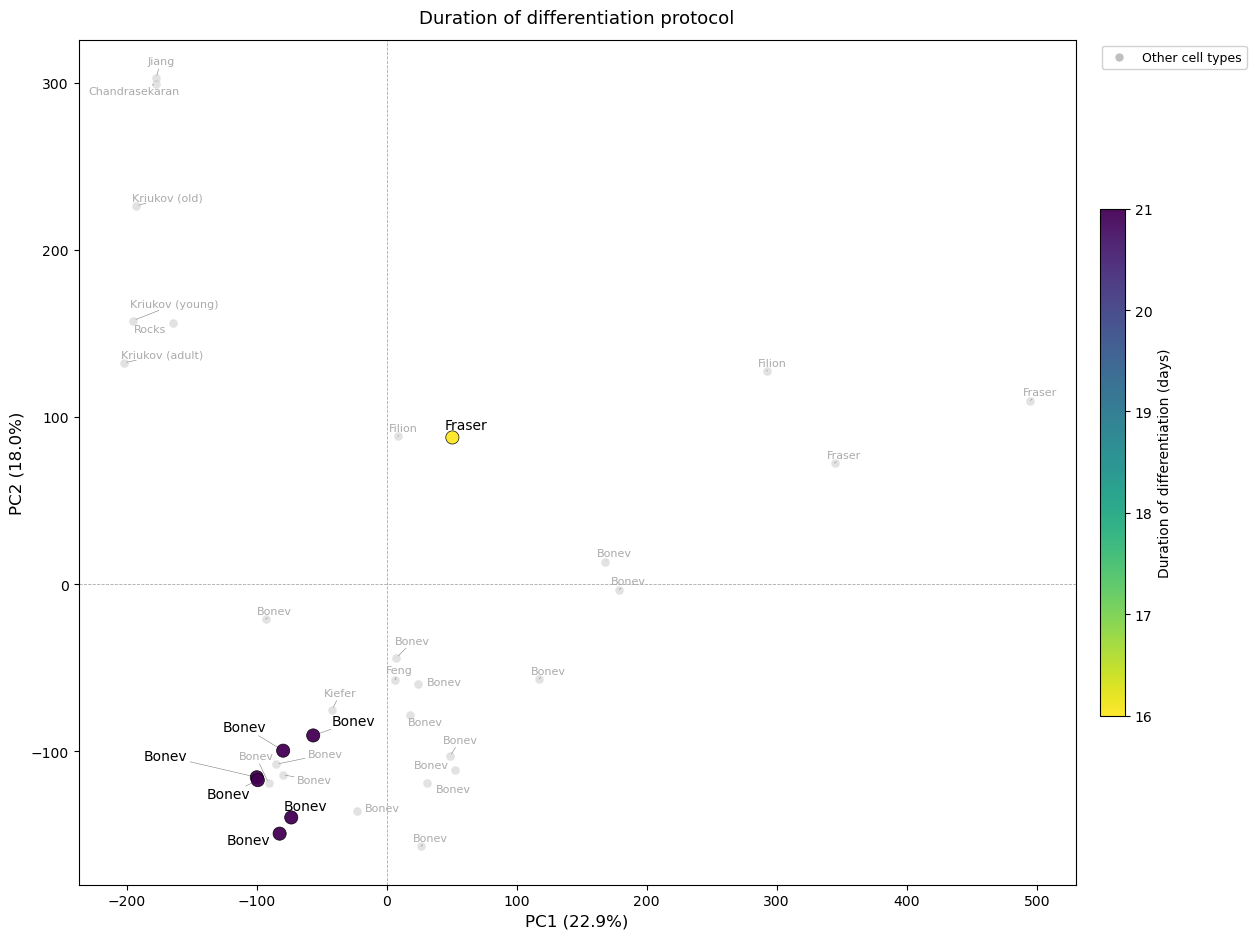

               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


Saved → ./pca_mouse_protocol_label.pdf


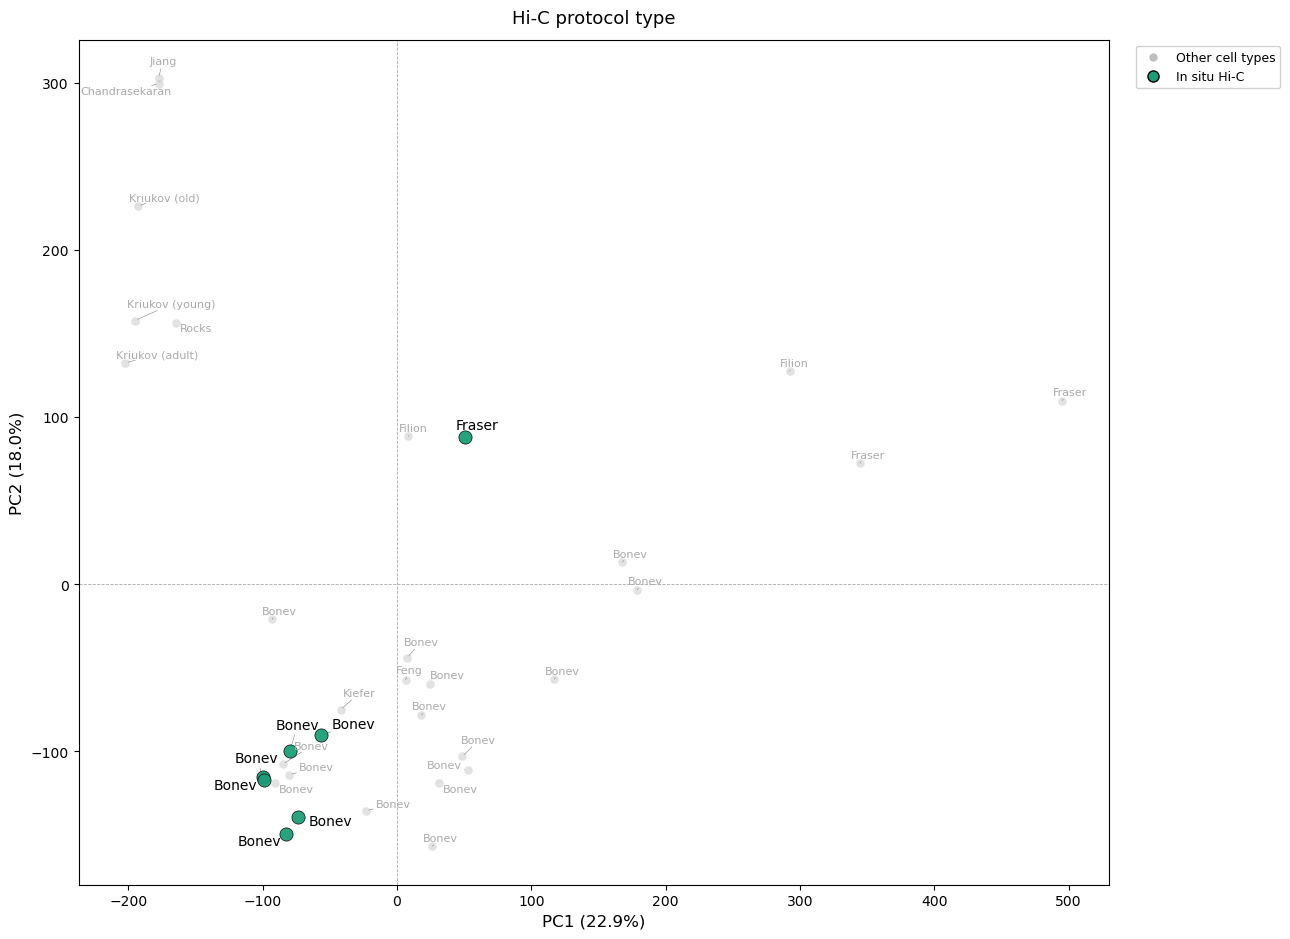

               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


Saved → ./pca_mouse_restriction_enzyme.pdf


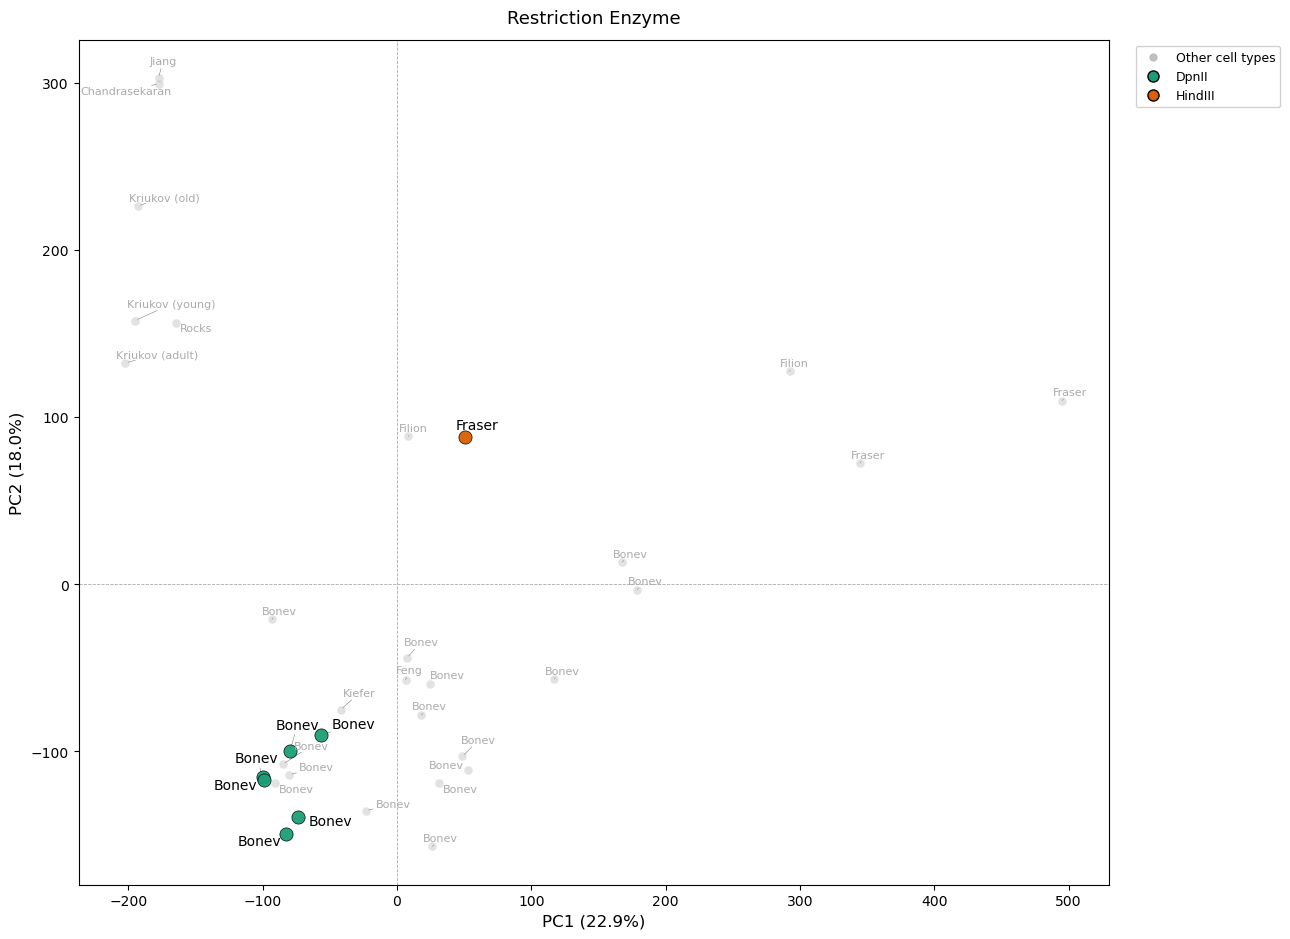

               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


Saved → ./pca_mouse_intended_subtypes.pdf


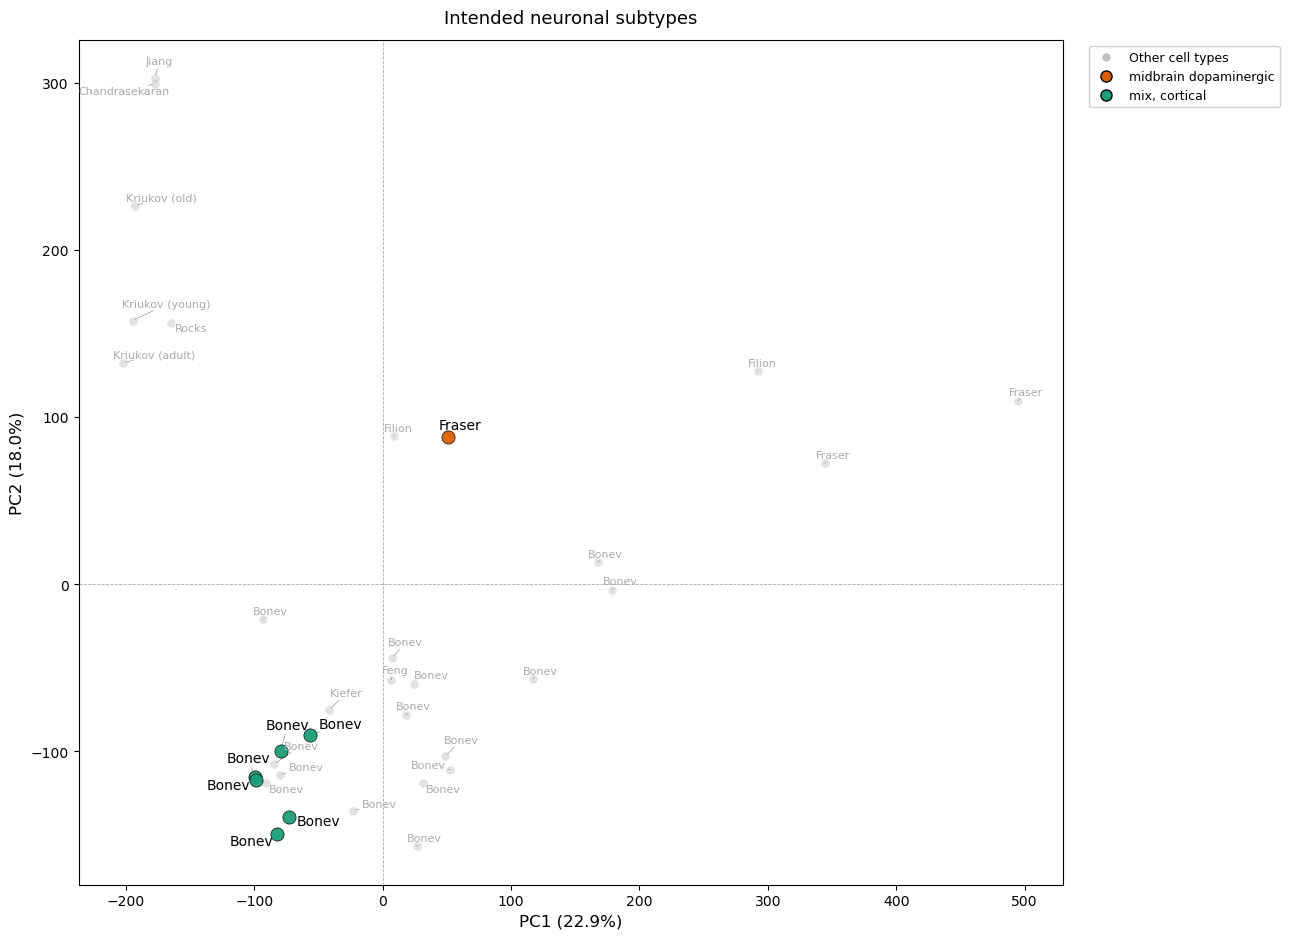

In [3]:
OUTPUT_DIR = "."  # change to desired output folder

PC1_VAR = 22.9  # % variance explained
PC2_VAR = 18.0

GREY = "#bfbfbf"
MISSING_COLOR = "#2b2b2b"  # dark charcoal for missing metadata
HIGHLIGHT_GROUP = "ESC-derived neurons"

# Categorical palettes – scientific, colorblind-friendly
# Protocol label palette (only 1 category)
PROTOCOL_PALETTE = {
    "In situ Hi-C": "#1b9e77",  # teal
}

# Restriction Enzyme palette (4 colors from ColorBrewer Dark2)
ENZYME_PALETTE = {
    "DpnII":   "#1b9e77",  # teal
    "HindIII": "#d95f02",  # orange
    "MboI":    "#7570b3",  # muted purple
    "NcoI":    "#e7298a",  # magenta-pink
}

# Intended subtypes palette (2 colors)
SUBTYPE_PALETTE = {
    "midbrain dopaminergic": "#d95f02",  # orange
    "mix, cortical":        "#1b9e77",  # teal
}

FIGSIZE = (13, 9.5)
DOT_SIZE_BG = 40
DOT_SIZE_FG = 90
ALPHA_BG = 0.45
ALPHA_FG = 0.95
LABEL_FONTSIZE_BG = 8
LABEL_FONTSIZE_FG = 10

# ──────────────────────────────────────────────────────────────────────────────
# 2. DATA LOADING & PREPARATION
# ──────────────────────────────────────────────────────────────────────────────


def load_data(data_path: str, metadata_path: str) -> pd.DataFrame:
    """Load PCA data and merge with ESC-derived neuron metadata."""
    df = pd.read_csv(data_path, sep="\t")
    df["group"] = df["Group"]
    df["PC1"] = pd.to_numeric(df["PC1"], errors="coerce")
    df["PC2"] = pd.to_numeric(df["PC2"], errors="coerce")
    if "sample_simple" not in df.columns:
        df["sample_simple"] = df["sample"]

    # Build merge key: author + celltype
    df["author"] = df["sample_simple"].astype(str).str.strip()
    df["celltype"] = df["group"].astype(str).str.strip()

    # Metadata
    meta = pd.read_csv(metadata_path)
    meta["author"] = meta["Author"].astype(str).str.strip()
    meta["celltype"] = meta["Celltype"].astype(str).str.strip()
    
    meta = meta[[
        "author",
        "celltype",
        "Duration of differentiation (days)",
        "Protocol label",
        "Restriction Enzyme",
        "Intended subtypes",
    ]]
    
    # Drop duplicates - keep first match for author+celltype
    # (Fraser has 2 rows with different enzymes, but TSV only has 1 Fraser neuron)
    meta = meta.drop_duplicates(subset=["author", "celltype"], keep="first")
    
    df = df.merge(meta, on=["author", "celltype"], how="left")

    # Strip whitespace from metadata string columns
    for col in ["Protocol label", "Restriction Enzyme", "Intended subtypes"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().replace({"nan": np.nan, "": np.nan})

    # Numeric duration
    def _extract_number(s):
        if pd.isna(s):
            return np.nan
        m = re.search(r"\d+", str(s))
        return float(m.group()) if m else np.nan

    df["duration_days"] = df["Duration of differentiation (days)"].apply(
        _extract_number
    )
    return df



def _add_labels(ax, df_subset, fontsize, color="dimgrey"):
    """Add sample_simple text labels and return the Text objects."""
    texts = []
    for _, row in df_subset.iterrows():
        t = ax.text(
            row["PC1"], row["PC2"],
            str(row["sample_simple"]),
            fontsize=fontsize,
            color=color,
            ha="right", va="bottom",
            zorder=5,
        )
        texts.append(t)
    return texts


def _base_ax(df: pd.DataFrame) -> tuple:
    """Create figure, plot grey background dots with labels, return (fig, ax, bg_texts)."""
    fig, ax = plt.subplots(figsize=FIGSIZE)

    bg = df[df["group"] != HIGHLIGHT_GROUP]
    ax.scatter(
        bg["PC1"],
        bg["PC2"],
        c=GREY,
        s=DOT_SIZE_BG,
        alpha=ALPHA_BG,
        edgecolors="white",
        linewidths=0.3,
        zorder=1,
        label="_nolegend_",
    )

    bg_texts = _add_labels(ax, bg, LABEL_FONTSIZE_BG, color="#aaaaaa")

    ax.axhline(0, color="darkgrey", ls="--", lw=0.6, zorder=0)
    ax.axvline(0, color="darkgrey", ls="--", lw=0.6, zorder=0)
    ax.set_xlabel(f"PC1 ({PC1_VAR}%)", fontsize=12)
    ax.set_ylabel(f"PC2 ({PC2_VAR}%)", fontsize=12)
    ax.tick_params(labelsize=10)
    return fig, ax, bg_texts


def _finish(fig, ax, title: str, fname: str, legend_handles=None, all_texts=None):
    """Add title, legend, adjust labels, save and show."""
    ax.set_title(title, fontsize=13, pad=12)
    if legend_handles is not None:
        ax.legend(
            handles=legend_handles,
            loc="upper left",
            bbox_to_anchor=(1.02, 1),
            fontsize=9,
            frameon=True,
            framealpha=0.9,
            title_fontsize=10,
        )
    if all_texts:
        adjust_text(
            all_texts, ax=ax,
            arrowprops=dict(arrowstyle="-", color="grey", lw=0.4),
            expand=(1.2, 1.4),
            force_text=(0.3, 0.5),
            only_move={"points": "y", "texts": "xy"},
        )
    fig.tight_layout()
    out = f"{OUTPUT_DIR}/{fname}"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"Saved → {out}")
    plt.show()


def _get_palette(series: pd.Series, predefined: dict) -> dict:
    """Return a palette dict covering every unique non-null value in *series*.

    Uses *predefined* colours where available; assigns new colours from tab10
    for any unseen categories.
    """
    unique_vals = sorted(series.dropna().unique(), key=str)
    palette = {}
    extra_idx = 0
    extra_colors = plt.cm.tab10.colors
    for v in unique_vals:
        if v in predefined:
            palette[v] = predefined[v]
        else:
            palette[v] = mcolors.to_hex(extra_colors[extra_idx % len(extra_colors)])
            extra_idx += 1
    return palette


# ──────────────────────────────────────────────────────────────────────────────
# 4. FIGURE FUNCTIONS
# ──────────────────────────────────────────────────────────────────────────────


def plot_duration(df: pd.DataFrame):
    """Fig 1 – ESC-derived neurons coloured by duration (continuous)."""
    fig, ax, bg_texts = _base_ax(df)
    fg = df[df["group"] == HIGHLIGHT_GROUP].copy()

    has_val = fg["duration_days"].notna()
    fg_miss = fg[~has_val]
    fg_good = fg[has_val]

    # Missing
    if not fg_miss.empty:
        ax.scatter(
            fg_miss["PC1"],
            fg_miss["PC2"],
            c=MISSING_COLOR,
            s=DOT_SIZE_FG,
            alpha=ALPHA_FG,
            edgecolors="k",
            linewidths=0.5,
            zorder=3,
            marker="X",
        )

    # Continuous colormap (reversed: lighter = fewer days, darker = more days)
    if not fg_good.empty:
        vmin = fg_good["duration_days"].min()
        vmax = fg_good["duration_days"].max()
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = cm.viridis_r  # reversed: light (yellow) = short, dark (purple) = long
        sc = ax.scatter(
            fg_good["PC1"],
            fg_good["PC2"],
            c=fg_good["duration_days"],
            cmap=cmap,
            norm=norm,
            s=DOT_SIZE_FG,
            alpha=ALPHA_FG,
            edgecolors="k",
            linewidths=0.5,
            zorder=3,
        )
        cbar = fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.02)
        cbar.set_label("Duration of differentiation (days)", fontsize=10)

    # Foreground labels
    fg_texts = _add_labels(ax, fg, LABEL_FONTSIZE_FG, color="black")

    # Legend for missing
    handles = []
    handles.append(
        Line2D([0], [0], marker="o", color="w", markerfacecolor=GREY,
               markersize=7, label="Other cell types", markeredgecolor="white")
    )
    if not fg_miss.empty:
        handles.append(
            Line2D([0], [0], marker="X", color="w", markerfacecolor=MISSING_COLOR,
                   markersize=8, label="ESC neurons (missing)", markeredgecolor="k")
        )
    _finish(fig, ax, "Duration of differentiation protocol",
            "pca_mouse_duration_continuous.pdf", handles, all_texts=bg_texts + fg_texts)


def plot_categorical(
    df: pd.DataFrame,
    col: str,
    predefined_palette: dict,
    title: str,
    fname: str,
):
    """Generic categorical colouring for ESC-derived neurons."""
    fig, ax, bg_texts = _base_ax(df)
    fg = df[df["group"] == HIGHLIGHT_GROUP].copy()

    palette = _get_palette(fg[col], predefined_palette)

    has_val = fg[col].notna()
    fg_miss = fg[~has_val]
    fg_good = fg[has_val]

    # Plot each category
    for cat, colour in palette.items():
        sub = fg_good[fg_good[col] == cat]
        if sub.empty:
            continue
        ax.scatter(
            sub["PC1"],
            sub["PC2"],
            c=colour,
            s=DOT_SIZE_FG,
            alpha=ALPHA_FG,
            edgecolors="k",
            linewidths=0.5,
            zorder=3,
        )

    # Missing
    if not fg_miss.empty:
        ax.scatter(
            fg_miss["PC1"],
            fg_miss["PC2"],
            c=MISSING_COLOR,
            s=DOT_SIZE_FG,
            alpha=ALPHA_FG,
            edgecolors="k",
            linewidths=0.5,
            zorder=3,
            marker="X",
        )

    # Foreground labels
    fg_texts = _add_labels(ax, fg, LABEL_FONTSIZE_FG, color="black")

    # Legend
    handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=GREY,
               markersize=7, label="Other cell types", markeredgecolor="white")
    ]
    for cat, colour in palette.items():
        handles.append(
            Line2D([0], [0], marker="o", color="w", markerfacecolor=colour,
                   markersize=8, label=str(cat), markeredgecolor="k")
        )
    if not fg_miss.empty:
        handles.append(
            Line2D([0], [0], marker="X", color="w", markerfacecolor=MISSING_COLOR,
                   markersize=8, label="Missing", markeredgecolor="k")
        )
    _finish(fig, ax, title, fname, handles, all_texts=bg_texts + fg_texts)


# ──────────────────────────────────────────────────────────────────────────────
# 5. MAIN
# ──────────────────────────────────────────────────────────────────────────────


def main():
    df = load_data(DATA_PATH, METADATA_PATH)

    # Fig 1 – Duration (continuous)
    plot_duration(df)

    # Fig 2 – Protocol label (categorical)
    plot_categorical(
        df,
        col="Protocol label",
        predefined_palette=PROTOCOL_PALETTE,
        title="Hi-C protocol type",
        fname="pca_mouse_protocol_label.pdf",
    )

    # Fig 3 – Restriction Enzyme (categorical)
    plot_categorical(
        df,
        col="Restriction Enzyme",
        predefined_palette=ENZYME_PALETTE,
        title="Restriction Enzyme",
        fname="pca_mouse_restriction_enzyme.pdf",
    )

    # Fig 4 – Intended subtypes (categorical)
    plot_categorical(
        df,
        col="Intended subtypes",
        predefined_palette=SUBTYPE_PALETTE,
        title="Intended neuronal subtypes",
        fname="pca_mouse_intended_subtypes.pdf",
    )


if __name__ == "__main__":
    main()



✓ All 34 samples successfully matched to metadata!

Saved → ./pca_mouse_all_enzyme.pdf
Saved → ./pca_mouse_all_enzyme.svg


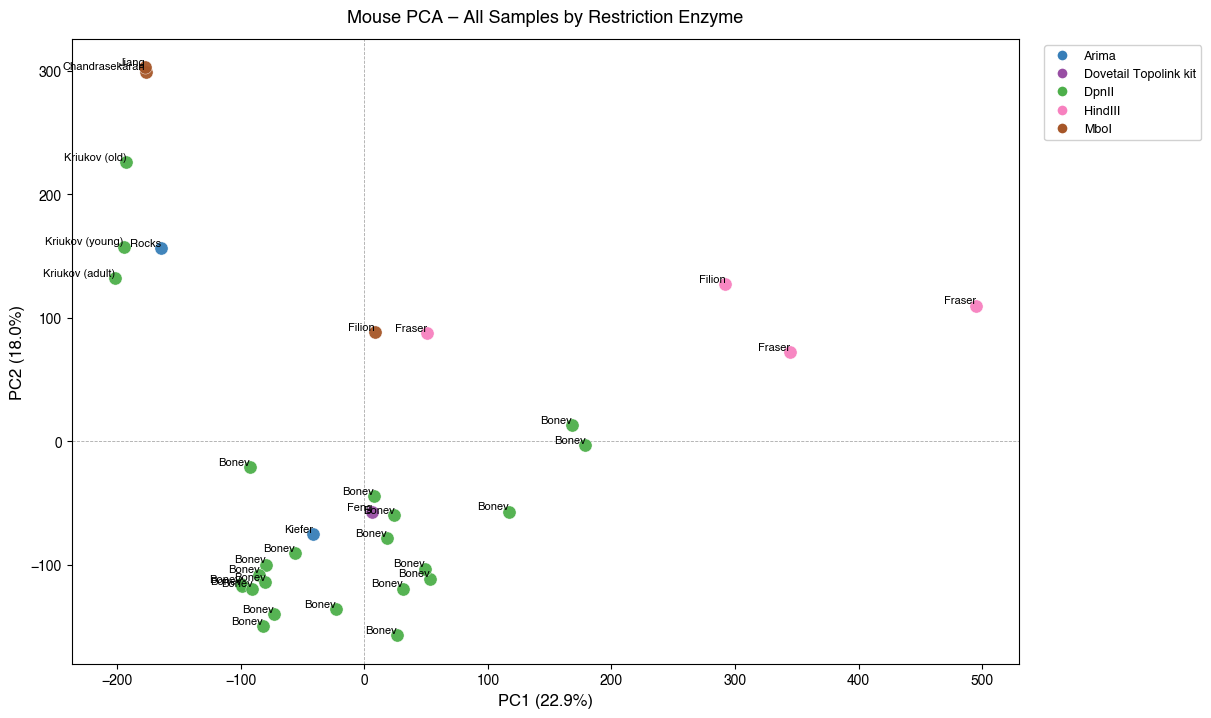

Saved → ./pca_mouse_all_duration.pdf
Saved → ./pca_mouse_all_duration.svg


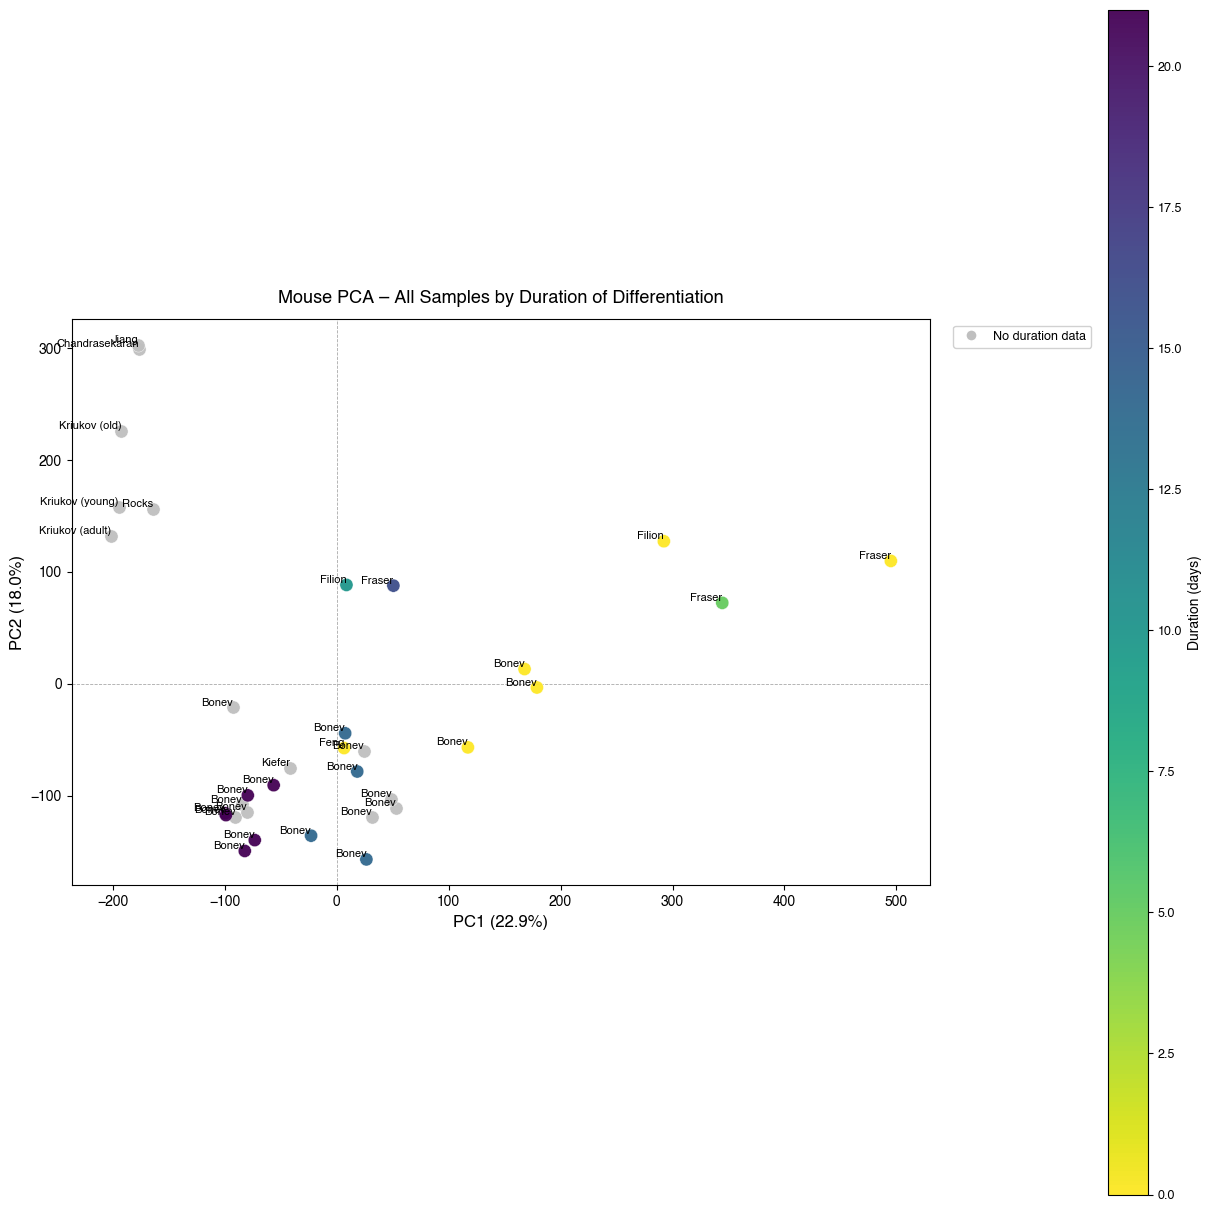

In [4]:
plt.rcParams["svg.fonttype"] = "none"

# Set font to Helvetica for consistent styling
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans"]
plt.rcParams["pdf.fonttype"] = 42  # TrueType fonts in PDF

OUTPUT_DIR = "."

PC1_VAR = 22.9  # % variance explained
PC2_VAR = 18.0

MISSING_COLOR = "#bfbfbf"  # grey for missing metadata

# Restriction Enzyme palette - same as human scripts for consistency
ENZYME_PALETTE = {
    "Arima":                "#377eb8",  # blue
    "Dovetail Topolink kit": "#984ea3",  # purple
    "DpnII":                "#4daf4a",  # green
    "HindIII":              "#f781bf",  # pink
    "MboI":                 "#a65628",  # brown
    "NcoI":                 "#e41a1c",  # red
    "-":                    "#ffff33",  # yellow (for missing/unknown)
}

FIGSIZE = (12, 12)  # Square aspect ratio
DOT_SIZE = 90
ALPHA = 0.95
LABEL_FONTSIZE = 8

# ──────────────────────────────────────────────────────────────────────────────
# 2. DATA LOADING & PREPARATION
# ──────────────────────────────────────────────────────────────────────────────


def load_data(data_path: str, metadata_path: str) -> pd.DataFrame:
    """Load PCA data and merge with metadata for all samples.
    
    Matching strategy:
    - TSV key: (sample_simple, Group)
    - Metadata key: (Author, Celltype)
    - Match on sample_simple -> Author AND Group -> Celltype
    """
    df = pd.read_csv(data_path, sep="\t")
    df["group"] = df["Group"].astype(str).str.strip()
    df["PC1"] = pd.to_numeric(df["PC1"], errors="coerce")
    df["PC2"] = pd.to_numeric(df["PC2"], errors="coerce")
    
    if "sample_simple" not in df.columns:
        df["sample_simple"] = df["sample"]
    df["sample_simple"] = df["sample_simple"].astype(str).str.strip()
    
    # Extract base author name for matching (handle "Kriukov (adult)" -> "Kriukov")
    def extract_author(s):
        if pd.isna(s):
            return ""
        # Extract text before parenthesis if present
        if "(" in str(s):
            return str(s).split("(")[0].strip()
        return str(s).strip()
    
    df["author_base"] = df["sample_simple"].apply(extract_author)

    # Metadata
    meta = pd.read_csv(metadata_path)
    meta["Author"] = meta["Author"].astype(str).str.strip()
    meta["Celltype"] = meta["Celltype"].astype(str).str.strip()
    
    # Strip whitespace from metadata string columns
    for col in ["Restriction Enzyme", "Duration of differentiation (days)", "Protocol label"]:
        if col in meta.columns:
            meta[col] = meta[col].astype(str).str.strip().replace({"nan": np.nan, "": np.nan})
    
    # Keep only relevant columns
    meta_cols = meta[["Author", "Celltype", "Restriction Enzyme", "Duration of differentiation (days)"]].copy()
    
    # Drop duplicates - keep first match for (Author, Celltype)
    meta_cols = meta_cols.drop_duplicates(subset=["Author", "Celltype"], keep="first")
    
    # Primary merge: exact match on sample_simple -> Author AND group -> Celltype
    df = df.merge(
        meta_cols,
        left_on=["sample_simple", "group"],
        right_on=["Author", "Celltype"],
        how="left",
        suffixes=("", "_exact")
    )
    
    # Fallback merge: for unmatched, try base author name
    still_missing = df["Restriction Enzyme"].isna()
    if still_missing.any():
        df_missing = df[still_missing].copy()
        df_missing = df_missing.merge(
            meta_cols,
            left_on=["author_base", "group"],
            right_on=["Author", "Celltype"],
            how="left",
            suffixes=("", "_fallback")
        )
        
        # Update main df with fallback matches
        for col in ["Restriction Enzyme", "Duration of differentiation (days)"]:
            fallback_col = col + "_fallback"
            if fallback_col in df_missing.columns:
                df.loc[still_missing, col] = df_missing[fallback_col].values
            elif col in df_missing.columns and df.loc[still_missing, col].isna().all():
                df.loc[still_missing, col] = df_missing[col].values
    
    # Extract numeric duration
    def _extract_number(s):
        if pd.isna(s):
            return np.nan
        m = re.search(r"\d+", str(s))
        return float(m.group()) if m else np.nan
    
    df["duration_days"] = df["Duration of differentiation (days)"].apply(_extract_number)
    
    # Report unmatched samples
    unmatched = df[df["Restriction Enzyme"].isna()]
    if not unmatched.empty:
        print("\n⚠️  WARNING: The following samples were NOT matched to metadata:")
        for _, row in unmatched.iterrows():
            print(f"   - {row['sample_simple']:20s} | {row['group']}")
        print(f"\nTotal unmatched: {len(unmatched)} out of {len(df)} samples\n")
    else:
        print(f"\n✓ All {len(df)} samples successfully matched to metadata!\n")
    
    return df


# ──────────────────────────────────────────────────────────────────────────────
# 3. PLOTTING HELPERS
# ──────────────────────────────────────────────────────────────────────────────


def _add_labels(ax, df_subset, fontsize, color="dimgrey"):
    """Add sample_simple text labels and return the Text objects."""
    texts = []
    for _, row in df_subset.iterrows():
        t = ax.text(
            row["PC1"], row["PC2"],
            str(row["sample_simple"]),
            fontsize=fontsize,
            color=color,
            ha="right", va="bottom",
            zorder=5,
        )
        texts.append(t)
    return texts


def _base_ax(df: pd.DataFrame) -> tuple:
    """Create figure and axes with grid lines."""
    fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)
    
    ax.axhline(0, color="darkgrey", ls="--", lw=0.6, zorder=0)
    ax.axvline(0, color="darkgrey", ls="--", lw=0.6, zorder=0)
    ax.set_xlabel(f"PC1 ({PC1_VAR}%)", fontsize=12)
    ax.set_ylabel(f"PC2 ({PC2_VAR}%)", fontsize=12)
    ax.tick_params(labelsize=10)
    ax.set_aspect('equal', adjustable='box')  # Make plot area square
    return fig, ax


def _finish(fig, ax, title: str, fname: str, legend_handles=None, all_texts=None):
    """Add title, legend, adjust labels, save and show."""
    ax.set_title(title, fontsize=13, pad=12)
    if legend_handles is not None:
        ax.legend(
            handles=legend_handles,
            loc="upper left",
            bbox_to_anchor=(1.02, 1),
            fontsize=9,
            frameon=True,
            framealpha=0.9,
            title_fontsize=10,
        )
    # Skip adjustText to avoid hanging with many labels
    # Labels may overlap but script will complete
    pass
    # Don't use tight_layout - constrained_layout is already set in subplots
    
    # Save both PDF and SVG formats
    base_name = fname.rsplit(".", 1)[0]  # Remove extension
    pdf_out = f"{OUTPUT_DIR}/{base_name}.pdf"
    svg_out = f"{OUTPUT_DIR}/{base_name}.svg"
    
    # Don't use bbox_inches='tight' as it can distort the square aspect ratio
    fig.savefig(pdf_out, dpi=300)
    fig.savefig(svg_out)
    
    print(f"Saved → {pdf_out}")
    print(f"Saved → {svg_out}")
    plt.show()


def _get_palette(series: pd.Series, predefined: dict) -> dict:
    """Return a palette dict covering every unique non-null value in series."""
    unique_vals = sorted(series.dropna().unique(), key=str)
    palette = {}
    extra_idx = 0
    extra_colors = plt.cm.tab10.colors
    for v in unique_vals:
        if v in predefined:
            palette[v] = predefined[v]
        else:
            palette[v] = mcolors.to_hex(extra_colors[extra_idx % len(extra_colors)])
            extra_idx += 1
    return palette


def plot_enzyme(df: pd.DataFrame):
    """Fig 1 – All samples colored by Restriction Enzyme (categorical)."""
    fig, ax = _base_ax(df)
    
    # Get palette
    palette = _get_palette(df["Restriction Enzyme"], ENZYME_PALETTE)
    
    # Separate missing and valid
    has_val = df["Restriction Enzyme"].notna()
    df_miss = df[~has_val]
    df_good = df[has_val]
    
    # Plot missing
    if not df_miss.empty:
        ax.scatter(
            df_miss["PC1"],
            df_miss["PC2"],
            c=MISSING_COLOR,
            s=DOT_SIZE,
            alpha=ALPHA,
            edgecolors="k",
            linewidths=0.5,
            zorder=2,
            marker="X",
            label="Missing",
        )
    
    # Plot each enzyme category
    legend_handles = []
    for enzyme, color in sorted(palette.items()):
        subset = df_good[df_good["Restriction Enzyme"] == enzyme]
        if not subset.empty:
            ax.scatter(
                subset["PC1"],
                subset["PC2"],
                c=color,
                s=DOT_SIZE,
                alpha=ALPHA,
                edgecolors="white",
                linewidths=0.3,
                zorder=3,
                label=enzyme,
            )
            legend_handles.append(
                Line2D([0], [0], marker="o", color="w", markerfacecolor=color,
                       markersize=8, label=enzyme)
            )
    
    # Add missing to legend if present
    if not df_miss.empty:
        legend_handles.append(
            Line2D([0], [0], marker="X", color="w", markerfacecolor=MISSING_COLOR,
                   markersize=8, label="Missing")
        )
    
    # Add labels
    all_texts = _add_labels(ax, df, LABEL_FONTSIZE, color="black")
    
    _finish(
        fig, ax,
        title="Mouse PCA – All Samples by Restriction Enzyme",
        fname="pca_mouse_all_enzyme.pdf",
        legend_handles=legend_handles,
        all_texts=all_texts,
    )


def plot_duration(df: pd.DataFrame):
    """Fig 2 – All samples colored by Duration (continuous, where available)."""
    fig, ax = _base_ax(df)
    
    # Separate samples with and without duration
    has_duration = df["duration_days"].notna()
    df_no_dur = df[~has_duration]
    df_with_dur = df[has_duration]
    
    # Plot samples without duration in grey
    if not df_no_dur.empty:
        ax.scatter(
            df_no_dur["PC1"],
            df_no_dur["PC2"],
            c=MISSING_COLOR,
            s=DOT_SIZE,
            alpha=ALPHA,
            edgecolors="white",
            linewidths=0.3,
            zorder=2,
            label="No duration data",
        )
    
    # Plot samples with duration using continuous colormap
    legend_handles = []
    if not df_with_dur.empty:
        vmin = df_with_dur["duration_days"].min()
        vmax = df_with_dur["duration_days"].max()
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = cm.viridis_r  # reversed: light (yellow) = short, dark (purple) = long
        
        sc = ax.scatter(
            df_with_dur["PC1"],
            df_with_dur["PC2"],
            c=df_with_dur["duration_days"],
            cmap=cmap,
            norm=norm,
            s=DOT_SIZE,
            alpha=ALPHA,
            edgecolors="white",
            linewidths=0.3,
            zorder=3,
        )
        
        # Add colorbar
        cbar = plt.colorbar(sc, ax=ax, pad=0.02, aspect=30)
        cbar.set_label("Duration (days)", fontsize=10)
        cbar.ax.tick_params(labelsize=9)
    
    # Add legend for no duration
    if not df_no_dur.empty:
        legend_handles.append(
            Line2D([0], [0], marker="o", color="w", markerfacecolor=MISSING_COLOR,
                   markersize=8, label="No duration data")
        )
    
    # Add labels
    all_texts = _add_labels(ax, df, LABEL_FONTSIZE, color="black")
    
    _finish(
        fig, ax,
        title="Mouse PCA – All Samples by Duration of Differentiation",
        fname="pca_mouse_all_duration.pdf",
        legend_handles=legend_handles if legend_handles else None,
        all_texts=all_texts,
    )


# ──────────────────────────────────────────────────────────────────────────────
# 5. MAIN
# ──────────────────────────────────────────────────────────────────────────────


def main():
    df = load_data(DATA_PATH, METADATA_PATH_ALL_SAMPLES)
    plot_enzyme(df)
    plot_duration(df)


if __name__ == "__main__":
    main()
